# Chapter 1 — Biosignals & Medical Images

### Companion notebook · *Biomedical Signal Processing & Data Analytics*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/farhad-abtahi/CM2013/blob/main/notebooks/ch01_biosignal_zoo.ipynb) [![View](https://img.shields.io/badge/view-static-orange)](https://farhad-abtahi.github.io/CM2013/nb/ch01_biosignal_zoo.html) [![JupyterLite](https://img.shields.io/badge/run-JupyterLite-blue)](https://farhad-abtahi.github.io/CM2013/lite/lab/index.html?path=ch01_biosignal_zoo.ipynb)

> **Motivating question.** Where do the wiggles in an ECG or EEG actually come from, and what makes a signal 'hard'?

## What this notebook demonstrates

- Origins of ECG / EEG / EMG and their signatures (EOG: amplitude/bandwidth only)
- Amplitude, bandwidth and rhythm as a signal 'fingerprint'
- Deterministic vs stochastic; stationary vs non-stationary

## What you'll do

You'll generate synthetic ECG, EEG, and EMG signals, compare their amplitude/bandwidth/rhythm "fingerprints," and practice identifying each from its signature alone — predicting the change before you run each cell.

## Runs in

| Platform | Status |
|---|---|
| **View (static)** | view only — outputs are pre-rendered |
| **Google Colab** | full, recommended |
| **JupyterLite** | full (synthetic data, NumPy/SciPy/sklearn only) |

**Data:** synthetic & reproducible (`SEED = 0`).  
**Runtime:** CPU, a few minutes.  
*All numbers below are illustrative and reproducible — not clinical benchmarks.*

## Setup: imports and shared helpers

These are the same building blocks the book's figures use; read them once, then reuse.

In [1]:
%matplotlib inline
import sys, os, subprocess

# --- get the shared modules (bookstyle, biosignals, and the bsp package) ---
# Local repo checkout: they sit in ../src (package) and ../src/bsp (modules).
# Colab / JupyterLite: clone the repo once.
for c in ("src", "../src", "src/bsp", "../src/bsp"):
    if os.path.isdir(c):
        sys.path.insert(0, os.path.abspath(c))
try:
    import bookstyle as bs, biosignals as bio
    from bsp.loaders import setup
except Exception:
    if "google.colab" in sys.modules:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        "pywavelets", "scikit-learn"], check=False)
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/farhad-abtahi/CM2013", "_bsp_repo"], check=False)
    for c in ("_bsp_repo/src", "_bsp_repo/src/bsp"):
        sys.path.insert(0, os.path.abspath(c))
    import bookstyle as bs, biosignals as bio
    from bsp.loaders import setup

import numpy as np
import matplotlib.pyplot as plt
from bsp.loaders import setup
SEED = 0
rng = setup(SEED)     # fixes the seed; all synthetic data below is reproducible


environment : local
seed        : 0  (all synthetic data is reproducible)


In [2]:
import numpy as np
import matplotlib.patches as mpatches

CH = 1

## 1.1 The biosignal zoo: EEG, ECG, EMG side by side

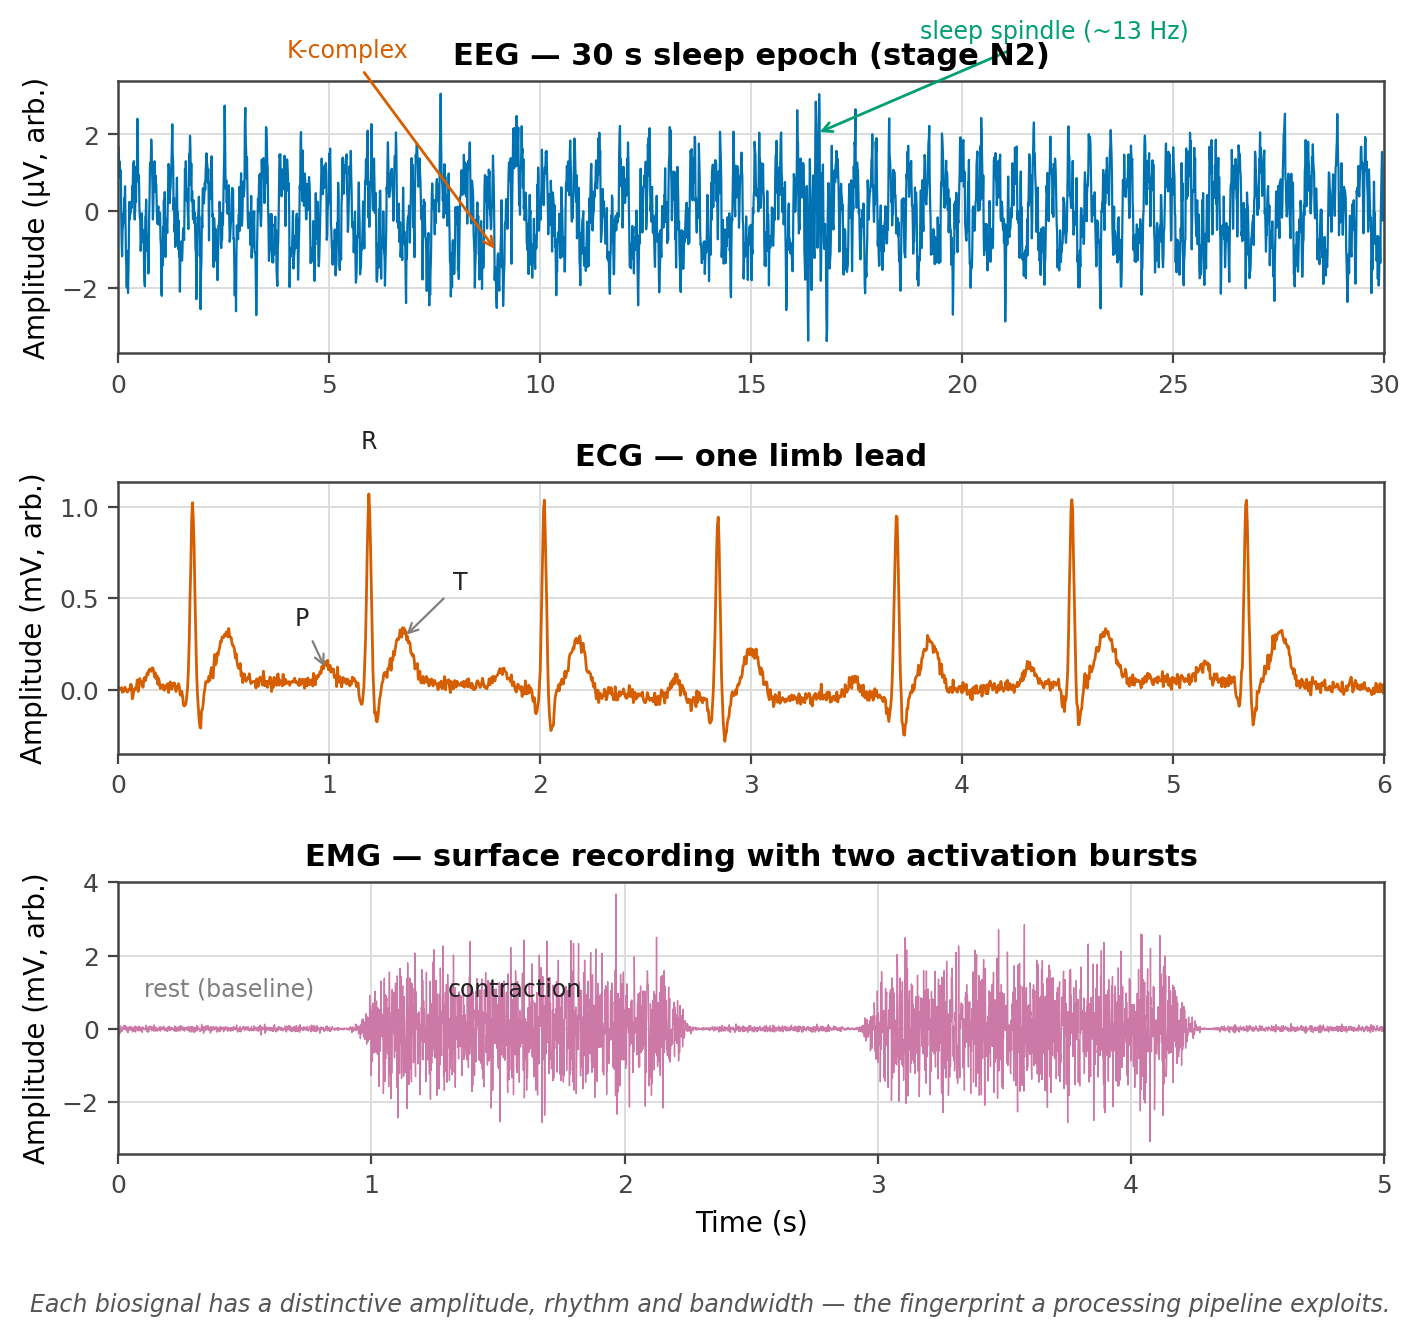

In [3]:
fig, ax = bs.newfig(w=7.2, h=6.4, nrows=3, ncols=1)

# --- EEG: 30 s N2 epoch with a spindle and a K-complex ---
t, x = bio.eeg(duration=30.0, fs=100, stage="N2")
ax[0].plot(t, x, color=bs.C["blue"], lw=0.8)
ax[0].set_title("EEG — 30 s sleep epoch (stage N2)")
ax[0].set_ylabel("Amplitude (µV, arb.)")
ax[0].set_xlim(0, 30)
ax[0].annotate("K-complex", xy=(9.0, x[int(9.0 * 100)]), xytext=(4, 4.0),
               fontsize=8.5, color=bs.C["red"],
               arrowprops=dict(arrowstyle="->", color=bs.C["red"], lw=1.0))
ax[0].annotate("sleep spindle (~13 Hz)", xy=(16.5, 2.0), xytext=(19, 4.5),
               fontsize=8.5, color=bs.C["green"],
               arrowprops=dict(arrowstyle="->", color=bs.C["green"], lw=1.0))

# --- ECG: a few beats of a limb lead ---
t, x = bio.ecg(duration=6.0, fs=256, hr=72)
ax[1].plot(t, x, color=bs.C["red"], lw=1.0)
ax[1].set_title("ECG — one limb lead")
ax[1].set_ylabel("Amplitude (mV, arb.)")
ax[1].set_xlim(0, 6)
# label one P-QRS-T complex — locate the 2nd R peak instead of hard-coding its
# time, since bio.ecg(hr=72) places it with jitter around ~1.18 s, not 1.15 s.
i0 = int(1.0 * 256)
ir = i0 + np.argmax(x[i0:int(1.4 * 256)])
tr = t[ir]
ax[1].annotate("R", xy=(tr, x[ir]), xytext=(tr, x[ir] + 0.25),
               fontsize=8.5, ha="center", color=bs.C["black"])
ax[1].annotate("P", xy=(tr - 0.20, 0.10), xytext=(tr - 0.35, 0.35),
               fontsize=8.5, color=bs.C["black"],
               arrowprops=dict(arrowstyle="->", color=bs.C["grey"], lw=0.8))
ax[1].annotate("T", xy=(tr + 0.16, 0.28), xytext=(tr + 0.40, 0.55),
               fontsize=8.5, color=bs.C["black"],
               arrowprops=dict(arrowstyle="->", color=bs.C["grey"], lw=0.8))

# --- EMG: two activation bursts ---
t, x = bio.emg_burst(duration=5.0, fs=1000, bursts=((1.0, 2.2), (3.0, 4.2)))
ax[2].plot(t, x, color=bs.C["purple"], lw=0.5)
ax[2].set_title("EMG — surface recording with two activation bursts")
ax[2].set_ylabel("Amplitude (mV, arb.)")
ax[2].set_xlabel("Time (s)")
ax[2].set_xlim(0, 5)
ax[2].annotate("rest (baseline)", xy=(0.4, 0.0), xytext=(0.1, 0.9),
               fontsize=8.5, color=bs.C["grey"])
ax[2].annotate("contraction", xy=(1.6, 0.0), xytext=(1.3, 0.9),
               fontsize=8.5, color=bs.C["black"])

bs.takeaway(fig, "Each biosignal has a distinctive amplitude, rhythm and "
                 "bandwidth — the fingerprint a processing pipeline exploits.")
plt.tight_layout()
plt.show()

## 1.2 A taxonomy of signal types

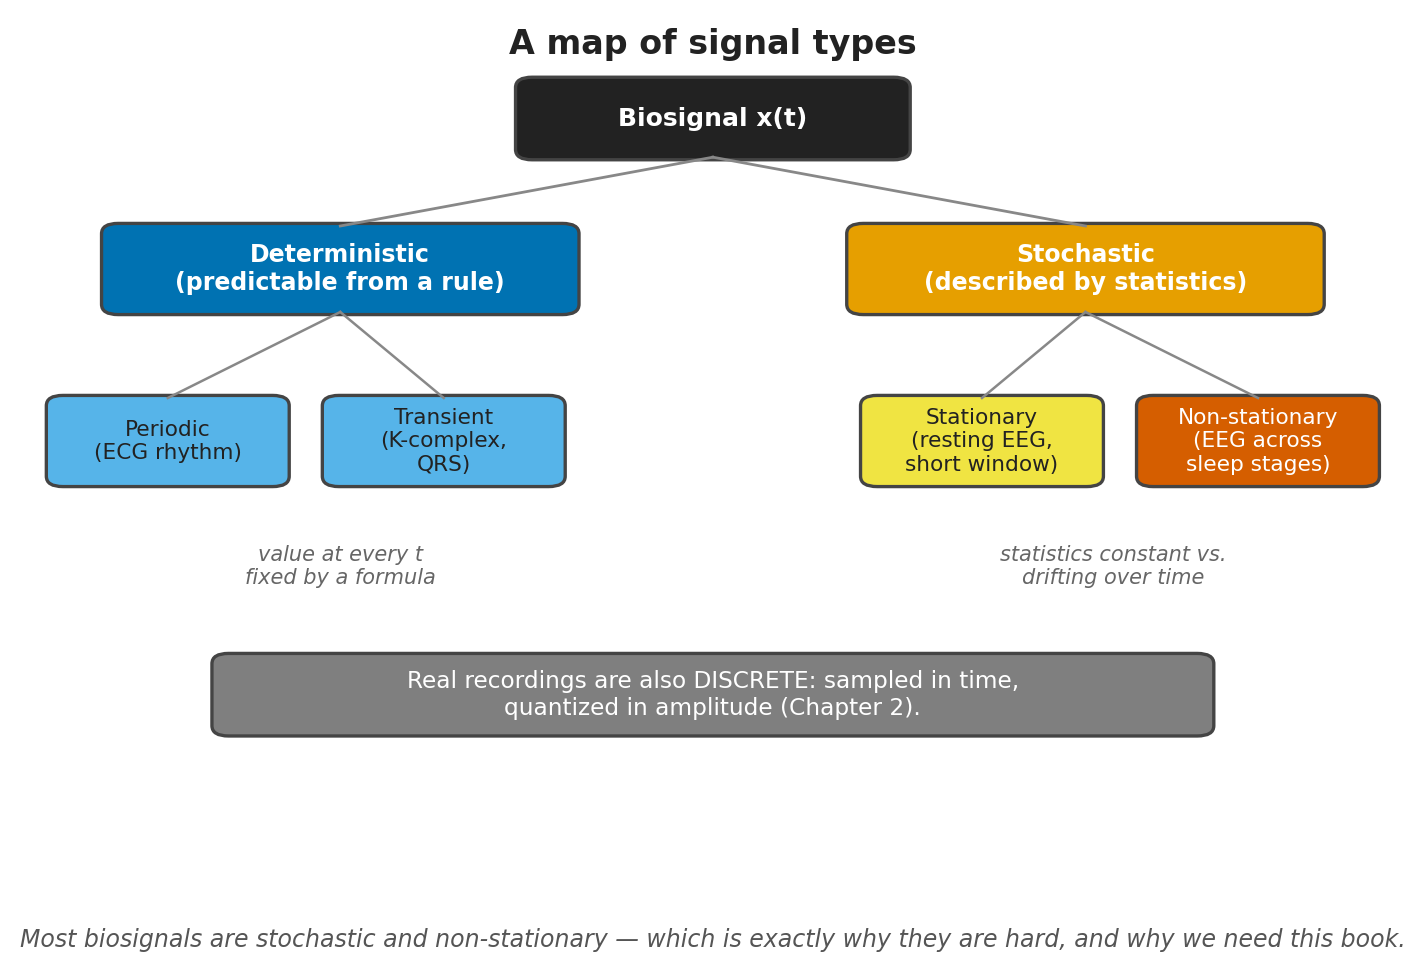

In [4]:
fig, ax = bs.newfig(w=7.2, h=4.6)
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis("off")
ax.grid(False)

def box(x, y, w, h, text, fc, tc="white", fs=9, weight="bold"):
    ax.add_patch(mpatches.FancyBboxPatch(
        (x, y), w, h, boxstyle="round,pad=0.03,rounding_size=0.12",
        linewidth=1.2, edgecolor="#444444", facecolor=fc))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center",
            fontsize=fs, color=tc, fontweight=weight, wrap=True)

ax.text(5, 9.6, "A map of signal types", ha="center", fontsize=12,
        fontweight="bold", color=bs.C["black"])

box(3.6, 8.4, 2.8, 0.9, "Biosignal x(t)", bs.C["black"])

# Level 1: deterministic vs stochastic
box(0.6, 6.6, 3.4, 1.0, "Deterministic\n(predictable from a rule)",
    bs.C["blue"], fs=8.5)
box(6.0, 6.6, 3.4, 1.0, "Stochastic\n(described by statistics)",
    bs.C["orange"], fs=8.5)
ax.plot([5, 2.3], [8.4, 7.6], color="#888888", lw=1.0)
ax.plot([5, 7.7], [8.4, 7.6], color="#888888", lw=1.0)

# Level 2 under deterministic
box(0.2, 4.6, 1.7, 1.0, "Periodic\n(ECG rhythm)", bs.C["sky"], tc="#222222",
    fs=7.8, weight="normal")
box(2.2, 4.6, 1.7, 1.0, "Transient\n(K-complex,\nQRS)", bs.C["sky"],
    tc="#222222", fs=7.8, weight="normal")
ax.plot([2.3, 1.05], [6.6, 5.6], color="#888888", lw=0.9)
ax.plot([2.3, 3.05], [6.6, 5.6], color="#888888", lw=0.9)

# Level 2 under stochastic: stationary vs non-stationary
box(6.1, 4.6, 1.7, 1.0, "Stationary\n(resting EEG,\nshort window)",
    bs.C["yellow"], tc="#222222", fs=7.8, weight="normal")
box(8.1, 4.6, 1.7, 1.0, "Non-stationary\n(EEG across\nsleep stages)",
    bs.C["red"], fs=7.8, weight="normal")
ax.plot([7.7, 6.95], [6.6, 5.6], color="#888888", lw=0.9)
ax.plot([7.7, 8.95], [6.6, 5.6], color="#888888", lw=0.9)

# foot notes
ax.text(2.3, 3.9, "value at every t\nfixed by a formula", ha="center",
        va="top", fontsize=7.5, style="italic", color="#666666")
ax.text(7.9, 3.9, "statistics constant vs.\ndrifting over time",
        ha="center", va="top", fontsize=7.5, style="italic", color="#666666")

# a continuous/discrete note strip along the bottom
box(1.4, 1.7, 7.2, 0.9,
    "Real recordings are also DISCRETE: sampled in time,\n"
    "quantized in amplitude (Chapter 2).", bs.C["grey"], fs=8.4,
    weight="normal")

bs.takeaway(fig, "Most biosignals are stochastic and non-stationary — which "
                 "is exactly why they are hard, and why we need this book.")
plt.tight_layout()
plt.show()

## 1.3 Typical bandwidth and amplitude ranges

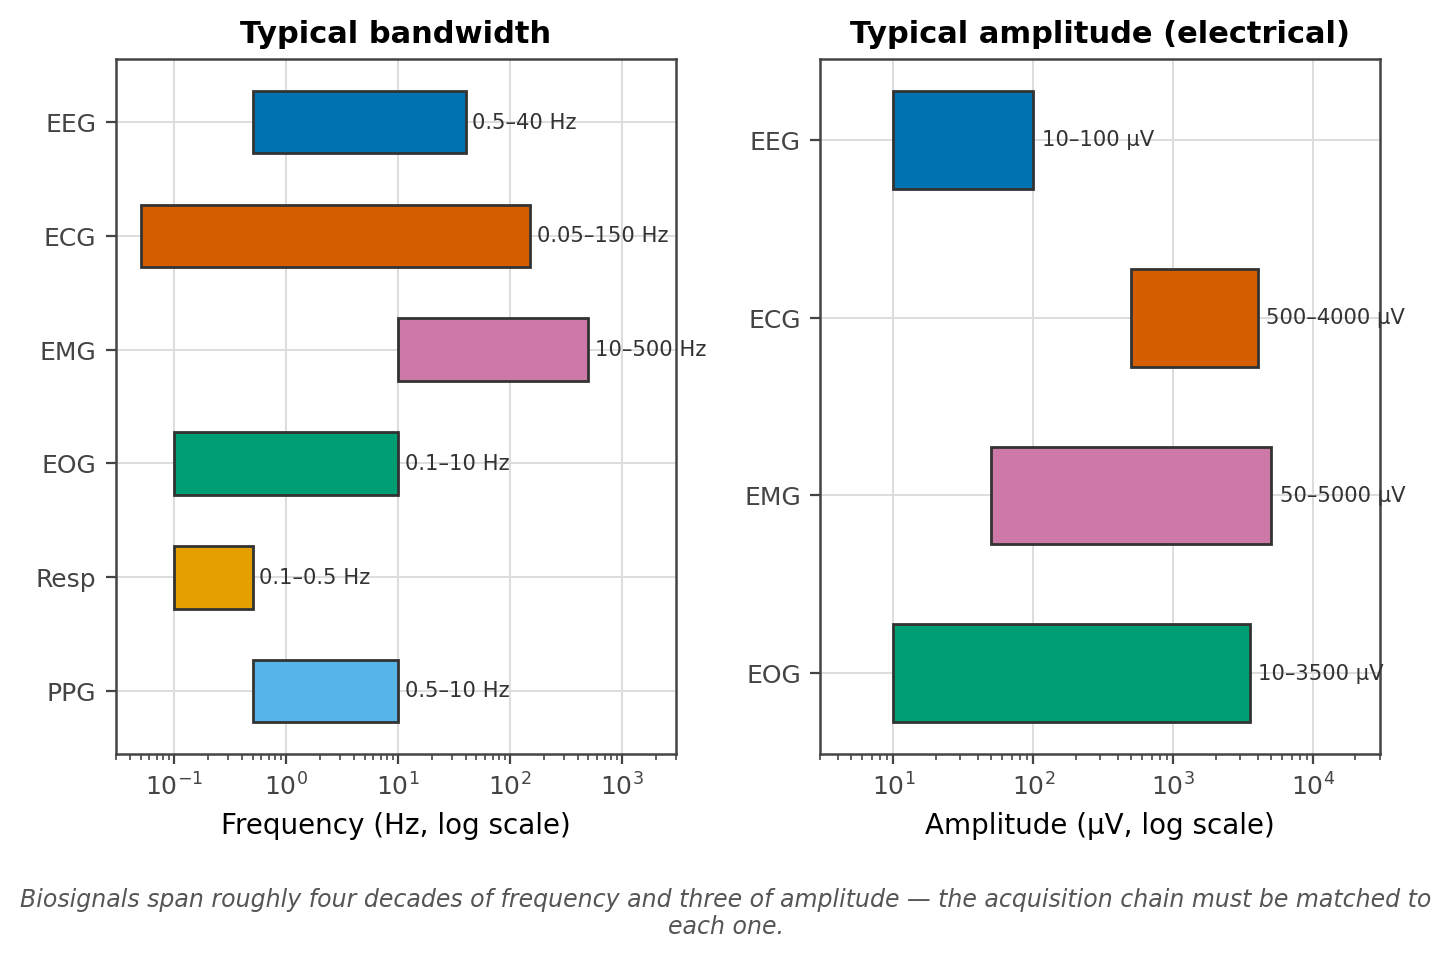

In [5]:
# (name, f_lo, f_hi, amp_lo, amp_hi) — typical clinical ranges
rows = [
    ("EEG",  0.5,  40.0, 10,   100),      # uV
    ("ECG",  0.05, 150.0, 500, 4000),     # uV (0.5-4 mV); diagnostic band per §1.4
    ("EMG",  10.0, 500.0, 50,  5000),     # uV
    ("EOG",  0.1,  10.0,  10,  3500),     # uV
    ("Resp", 0.1,  0.5,   None, None),    # mechanical (6-30 breaths/min)
    ("PPG",  0.5,  10.0,  None, None),    # optical
]
fig, ax = bs.newfig(w=7.2, h=4.4, ncols=2)

# --- left: frequency band (log x) ---
axf = ax[0]
ypos = np.arange(len(rows))[::-1]
cols = [bs.C["blue"], bs.C["red"], bs.C["purple"], bs.C["green"],
        bs.C["orange"], bs.C["sky"]]
for y, (name, flo, fhi, *_), c in zip(ypos, rows, cols):
    axf.barh(y, fhi - flo, left=flo, color=c, edgecolor="#333333",
             height=0.55)
    axf.text(fhi * 1.15, y, f"{flo:g}–{fhi:g} Hz", va="center",
             fontsize=7.6, color="#333333")
axf.set_xscale("log")
axf.set_xlim(0.03, 3000)
axf.set_yticks(ypos)
axf.set_yticklabels([r[0] for r in rows])
axf.set_xlabel("Frequency (Hz, log scale)")
axf.set_title("Typical bandwidth")

# --- right: amplitude (log x), only for electrical signals ---
axa = ax[1]
erows = [r for r in rows if r[3] is not None]
ypos2 = np.arange(len(erows))[::-1]
ecols = [bs.C["blue"], bs.C["red"], bs.C["purple"], bs.C["green"]]
for y, (name, flo, fhi, alo, ahi), c in zip(ypos2, erows, ecols):
    axa.barh(y, ahi - alo, left=alo, color=c, edgecolor="#333333",
             height=0.55)
    axa.text(ahi * 1.15, y, f"{alo:g}–{ahi:g} µV", va="center",
             fontsize=7.6, color="#333333")
axa.set_xscale("log")
axa.set_xlim(3, 3e4)
axa.set_yticks(ypos2)
axa.set_yticklabels([r[0] for r in erows])
axa.set_xlabel("Amplitude (µV, log scale)")
axa.set_title("Typical amplitude (electrical)")

bs.takeaway(fig, "Biosignals span roughly four decades of frequency and three of amplitude — "
                 "the acquisition chain must be matched to each one.")
plt.tight_layout()
plt.show()

## Expected outputs (reproducibility)

Because `SEED = 0`, re-running reproduces the figures above exactly. Change a parameter and watch them move — that loop between the page and the running code is where the intuition forms.

## MATLAB equivalent

The worked code here is Python-primary. The nearest MATLAB calls:

> Plot signals with `plot(t,x)`.

## Student tasks


Each task has a collapsible **hint** — commit your prediction *before* you open it.


**1.** Comment out the three `set_title` calls and the `annotate` calls in the 1.1 cell, re-run, and write which panel is which plus the two cues you used (amplitude scale, rhythm).

<details><summary>💡 Hint &amp; what you should see</summary>

ECG has the sharpest, most periodic spikes (QRS, ~1 Hz, ~1 mV); EEG is the lowest-amplitude, most irregular (µV, broadband 0.5–40 Hz); EMG is bursty/high-bandwidth. Match each trace to its amplitude range **and** its rhythm.

</details>

**2.** (conceptual — no code) Which three channels does sleep staging need, and why (EEG rhythm, EOG eye movement, EMG atonia)?

<details><summary>💡 Hint &amp; what you should see</summary>

EEG (cortical rhythms — alpha, spindles, slow waves separate the stages), EOG (eye movements mark REM and wake), EMG (chin atonia confirms REM vs wake). You need all three because **no single channel** separates all five stages.

</details>

In [6]:
# Your workspace — attempt the tasks above.
# Tip: copy a figure cell, change ONE parameter, predict, then re-run.


---
*Companion notebook for **Biomedical Signal Processing & Data Analytics: From Physiology to Machine Learning**. Synthetic data; illustrative numbers. Generated from `figures_src/ch01_figures.py`.*